🔍 Analyzing dataset at: D:\Backup\WORK\MACH-3D\DefectClassification\Cleaned_dataset
✅ Found 8 classes: ['blobs', 'cracks', 'over_extrusion', 'spaghetti', 'stringing', 'under_extrusion', 'layer_shift', 'warp']
   Processing train (25972 images)...
   Processing valid (7420 images)...
   Processing test (3711 images)...

📊 Graph saved to: D:\Backup\WORK\MACH-3D\DefectClassification\Cleaned_dataset\class_distribution.png


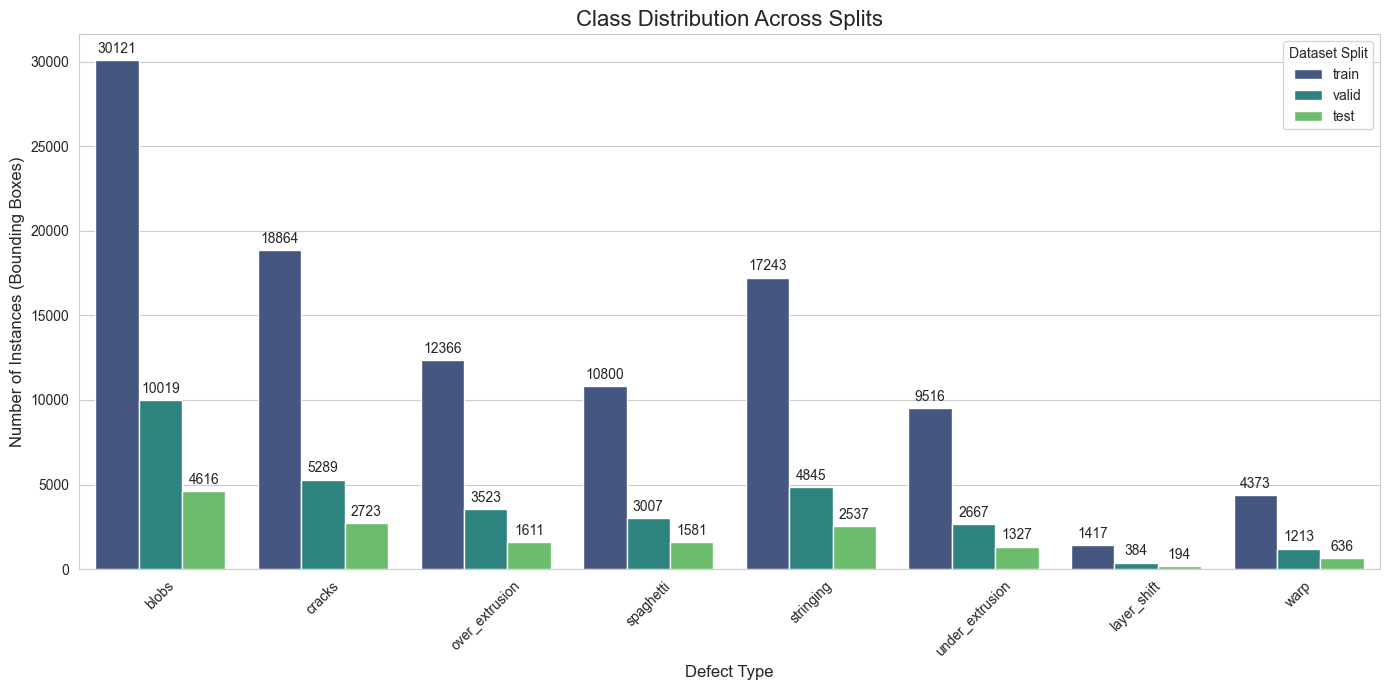

In [ ]:
import os
import glob
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ================= CONFIGURATION =================
# Path to your dataset root folder (containing data.yaml, train, valid, test)
DATASET_DIR = r'D:\Backup\WORK\MACH-3D\DefectClassification\Cleaned_dataset_OBB'  # <--- UPDATE THIS PATH IF NEEDED

def plot_dataset_distribution(dataset_root):
    print(f"🔍 Analyzing dataset at: {dataset_root}")
    
    # 1. Load Class Names from data.yaml
    yaml_path = os.path.join(dataset_root, 'data.yaml')
    if not os.path.exists(yaml_path):
        print("❌ Error: data.yaml not found!")
        return

    with open(yaml_path, 'r') as f:
        data_cfg = yaml.safe_load(f)
        
    # Handle different yaml formats (list vs dict)
    if isinstance(data_cfg['names'], dict):
        class_names = [data_cfg['names'][i] for i in sorted(data_cfg['names'].keys())]
    else:
        class_names = data_cfg['names']
        
    print(f"✅ Found {len(class_names)} classes: {class_names}")

    # 2. Count Instances per Split
    # Map 'val' or 'valid' folder names standardly
    splits = ['train', 'valid', 'test']
    
    # Data storage for plotting
    stats = []

    for split in splits:
        # Check if folder exists (some datasets use 'val' instead of 'valid')
        split_path = os.path.join(dataset_root, split)
        if not os.path.exists(split_path) and split == 'valid':
             split_path = os.path.join(dataset_root, 'val')
        
        if not os.path.exists(split_path):
            print(f"⚠️ Skipping missing split: {split}")
            continue

        label_dir = os.path.join(split_path, 'labels')
        label_files = glob.glob(os.path.join(label_dir, '*.txt'))
        
        print(f"   Processing {split} ({len(label_files)} images)...")
        
        # Count classes in this split
        for lbl_file in label_files:
            with open(lbl_file, 'r') as f:
                lines = f.readlines()
                for line in lines:
                    try:
                        class_id = int(line.split()[0])
                        if class_id < len(class_names):
                            name = class_names[class_id]
                            stats.append({'Split': split, 'Class': name})
                    except (ValueError, IndexError):
                        pass

    # 3. Create DataFrame & Plot
    if not stats:
        print("❌ No labels found to plot.")
        return

    df = pd.DataFrame(stats)

    # Plot Settings
    plt.figure(figsize=(14, 7))
    sns.set_style("whitegrid")
    
    # Create a countplot with 'hue' for splits (Train/Val/Test)
    ax = sns.countplot(data=df, x='Class', hue='Split', order=class_names, palette='viridis')
    
    # Add counts on top of bars
    for container in ax.containers:
        ax.bar_label(container, padding=3)

    plt.title('Class Distribution Across Splits', fontsize=16)
    plt.xlabel('Defect Type', fontsize=12)
    plt.ylabel('Number of Instances (Bounding Boxes)', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title='Dataset Split')
    plt.tight_layout()
    
    # Save and Show
    save_path = os.path.join(dataset_root, 'class_distribution.png')
    plt.savefig(save_path)
    print(f"\n📊 Graph saved to: {save_path}")
    plt.show()


plot_dataset_distribution(DATASET_DIR)



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.stats import entropy
import os
from PIL import Image

def get_train_variance(main_folder_path, target_size=(16, 16)):
    """
    Loads images recursively from the 'train' subdirectory of the main folder.
    """
    # construct path to the train split specifically
    train_path = os.path.join(main_folder_path, 'train')
    
    image_data = []
    print(f"--- Scanning for images in: {train_path} ---")
    
    if not os.path.exists(train_path):
        print(f"Error: The folder '{train_path}' does not exist.")
        print("Please check that your main folder contains a 'train' folder.")
        return

    # os.walk will go into train/spaghetti, train/layer_shift, etc.
    supported_exts = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')
    
    for root, dirs, files in os.walk(train_path):
        for filename in files:
            if filename.lower().endswith(supported_exts):
                img_path = os.path.join(root, filename)
                try:
                    # Open, convert to grayscale, resize, and normalize
                    with Image.open(img_path).convert('L') as img:
                        img = img.resize(target_size)
                        img_arr = np.array(img).flatten() / 255.0
                        image_data.append(img_arr)
                except Exception as e:
                    pass # Skip corrupt files silently

    # Convert to numpy array
    X = np.array(image_data)
    
    # VALIDATION CHECK
    print(f"Successfully loaded {len(X)} images.")
    if len(X) < 2:
        print("CRITICAL: Need at least 2 images to calculate variance.")
        return

    # --- PCA Calculation ---
    print("Running PCA...")
    # Max components is min(samples, features)
    n_components = min(X.shape[0], X.shape[1])
    pca = PCA(n_components=n_components)
    pca.fit(X)

    # --- Metrics ---
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    n_95 = np.argmax(cumulative_variance >= 0.95) + 1
    
    singular_vals = pca.singular_values_
    p = singular_vals / np.sum(singular_vals)
    svd_entropy = entropy(p)

    print(f"-"*30)
    print(f"RESULTS FOR TRAIN SPLIT:")
    print(f"Total Components Possible: {n_components}")
    print(f"Components for 95% Variance: {n_95}")
    print(f"Dataset Entropy: {svd_entropy:.4f}")
    print(f"-"*30)

    # --- Plot ---
    plt.figure(figsize=(10, 6))
    plt.plot(cumulative_variance, linewidth=2)
    plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
    plt.axvline(x=n_95, color='r', linestyle='--', label=f'95% Explained at {n_95}')
    plt.xlabel('Number of Principal Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title(f'Variance Analysis: Train Split ({len(X)} images)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# --- RUN IT ---
# Paste your MAIN folder path here (the one holding train/test/valid)
# Example: r"C:\Users\Name\Desktop\3D_Print_Data"
main_folder = r"D:\Backup\WORK\MACH-3D\DefectClassification\Cleaned_dataset_OBB" 

get_train_variance(main_folder)

--- Scanning for images in: D:\Backup\WORK\MACH-3D\DefectClassification\Cleaned_dataset\train ---


MemoryError: Unable to allocate 50.7 GiB for an array with shape (25964, 262144) and data type float64

--- Scanning for labels in: D:\Backup\WORK\MACH-3D\DefectClassification\Cleaned_dataset\train ---
Successfully analyzed 25972 label files.


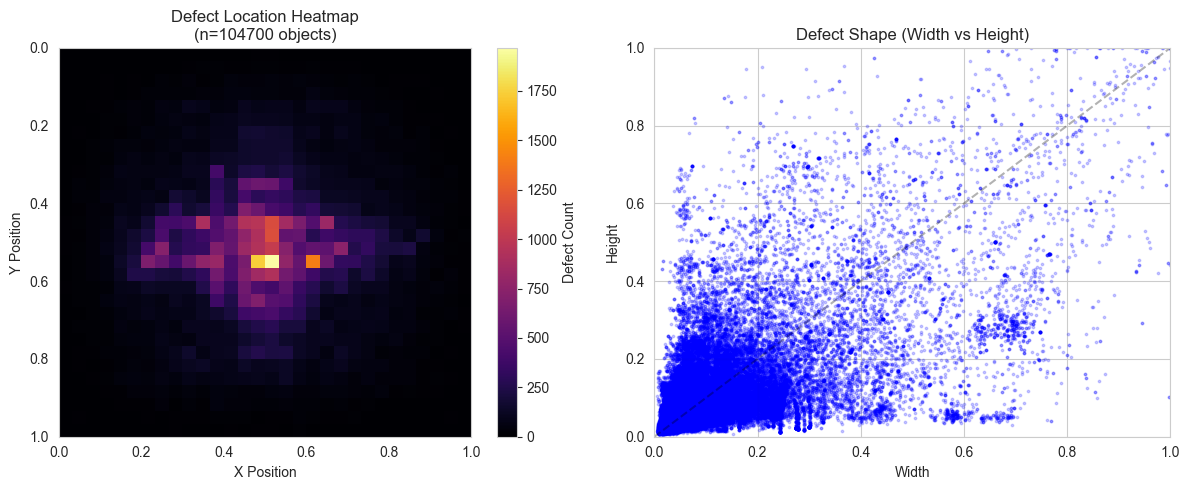

In [3]:
import os
import matplotlib.pyplot as plt
import numpy as np

def analyze_yolo_labels_recursive(label_folder_path):
    """
    Recursively scans for YOLO .txt labels in all subfolders
    and visualizes dataset diversity.
    """
    box_centers_x = []
    box_centers_y = []
    box_widths = []
    box_heights = []
    
    file_count = 0
    
    print(f"--- Scanning for labels in: {label_folder_path} ---")
    
    # 1. Walk through all subdirectories
    for root, dirs, files in os.walk(label_folder_path):
        for filename in files:
            if filename.endswith('.txt'):
                file_count += 1
                file_path = os.path.join(root, filename)
                
                # 2. Parse the file
                try:
                    with open(file_path, 'r') as f:
                        lines = f.readlines()
                        for line in lines:
                            parts = line.strip().split()
                            # Check for valid YOLO line (class + 4 coords)
                            if len(parts) >= 5:
                                _, x, y, w, h = map(float, parts[:5])
                                box_centers_x.append(x)
                                box_centers_y.append(y)
                                box_widths.append(w)
                                box_heights.append(h)
                except Exception as e:
                    print(f"Skipping corrupt file {filename}: {e}")

    print(f"Successfully analyzed {file_count} label files.")
    
    if file_count == 0:
        print("ERROR: Still found 0 labels. Please verify:")
        print("1. Does this folder contain .txt files?")
        print("2. Are you pointing to the 'labels' folder, not the 'images' folder?")
        return

    # --- Plotting ---
    plt.figure(figsize=(12, 5))
    
    # Plot 1: Heatmap
    plt.subplot(1, 2, 1)
    plt.hist2d(box_centers_x, box_centers_y, bins=30, cmap='inferno', range=[[0, 1], [0, 1]])
    plt.colorbar(label='Defect Count')
    plt.gca().invert_yaxis() # Invert Y to match image coordinates (top-left is 0,0)
    plt.title(f'Defect Location Heatmap\n(n={len(box_centers_x)} objects)')
    plt.xlabel('X Position')
    plt.ylabel('Y Position')

    # Plot 2: Size Scatter
    plt.subplot(1, 2, 2)
    plt.scatter(box_widths, box_heights, alpha=0.2, s=3, c='blue')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.plot([0,1], [0,1], 'k--', alpha=0.3) # Reference diagonal line
    plt.title('Defect Shape (Width vs Height)')
    plt.xlabel('Width')
    plt.ylabel('Height')
    
    plt.tight_layout()
    plt.show()

# --- USAGE ---
# Point this to the main folder containing your labels
# Example: r"C:\MyProject\dataset\labels\train"
label_path = r"D:\Backup\WORK\MACH-3D\DefectClassification\Cleaned_dataset\train" 

analyze_yolo_labels_recursive(label_path)